In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/Clean_Text_Glassdoor - cleaned_glassdoor_reviews.csv')
df

,review_id,rating_date,employee_length,employee_status,employee_type,flags_business_outlook,flags_ceo_approval,flags_recommend_frend,rating_culture_values,rating_diversity_inclusion,rating_overall,rating_work_life,career_opportunities_rating,employee_location,employee_job_title,advice_to_management,review_pros,review_cons,rating_senior_leadership,rating_compensation_benefits
0,1,2025-06-03T00:00:00.000Z,0,REGULAR,Current employee,NAN,NAN,NAN,0.0,0.0,3,0.0,NaN,"Richmond, VA",Warehouse Fulfillment Associate,don’t micro manage,interactive leave take whenever long time easy...,inhumane draining physically amp mentally,0.0,0.0
1,2,2025-05-29T00:00:00.000Z,1,CONTRACT,"Current employee, less than 1 year",POSITIVE,APPROVE,POSITIVE,5.0,5.0,4,3.0,NaN,"Brampton, ON",Warehouse Associate,remove attitude manager warehouse,good easy work enviorment,sticks rules completing targets otherwise get ...,3.0,5.0
2,3,2025-05-28T00:00:00.000Z,1,REGULAR,"Current employee, less than 1 year",POSITIVE,APPROVE,POSITIVE,5.0,5.0,5,5.0,NaN,"Bolton, ON",Warehouse Associate,NaN,help grow good pay,limited opportunities advancementno clear path...,5.0,5.0
3,4,2025-05-26T00:00:00.000Z,2,PART_TIME,Current employees,POSITIVE,APPROVE,POSITIVE,2.0,2.0,3,2.0,NaN,"Swedesboro, NJ",Employee,NaN,plenty work meet new people,tough body labor intensive,2.0,2.0
4,5,2025-05-23T00:00:00.000Z,0,REGULAR,Current employee,NAN,NAN,NAN,0.0,0.0,4,0.0,NaN,"Whitby, ON",Fulfillment Associate,NaN,good holiday pay additional benefits permanent...,hiring permanent employees directly,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,137,2026-01-31T00:00:00.000Z,<1,REGULAR,Former Employee,NAN,NAN,NAN,NaN,NaN,5,NaN,NaN,"Hamilton, ON",Associate,NaN,good pay ot,fast pace work long hours,NaN,NaN
129,138,2026-01-29T00:00:00.000Z,3+,REGULAR,Current Employee,POSITIVE,NEUTRAL,POSITIVE,2.0,5.0,4,3.0,4.0,"Charlotte, NC",Associate,get closer eith people bellow,good pay opportunities growth,long hours mandatory ot peak seasons,4.0,5.0
130,139,2026-01-28T00:00:00.000Z,NaN,REGULAR,Former Employee,NAN,NAN,NAN,NaN,NaN,5,NaN,NaN,NaN,Area Manager,NaN,pay amazing balanced,work load demanding,NaN,NaN
131,140,2026-01-28T00:00:00.000Z,NaN,REGULAR,Former Employee,NAN,NAN,NAN,NaN,NaN,4,NaN,NaN,"Sacramento, CA",Associate,NaN,work straightforward easy pick,shifts hours change depending demand making ha...,NaN,NaN


In [ ]:
df = df.dropna(subset=['review_pros'])

In [ ]:
from collections import Counter

all_words = ' '.join(df['review_pros']).split()
word_count = Counter(all_words)

In [ ]:
print(word_count.most_common(5))

[('good', 50), ('pay', 48), ('work', 36), ('benefits', 36), ('great', 18)]


In [ ]:
word_df = pd.DataFrame(word_count.items(), columns=['word', 'count']).sort_values(by = 'count', ascending = False)
word_df

,word,count
8,good,50
12,pay,48
19,benefits,36
7,work,36
23,great,18
...,...,...
412,straightforward,1
411,balanced,1
410,amazing,1
409,goes,1


In [ ]:
most_common = word_count.most_common(10)
words, counts = zip(*most_common)

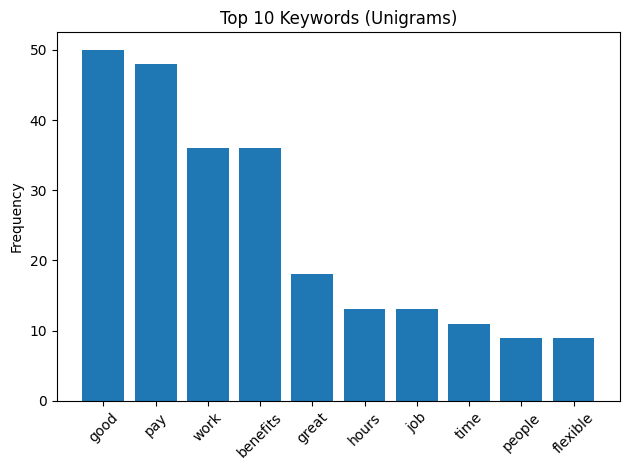

In [ ]:
plt.bar(words, counts)
plt.title("Top 10 Keywords (Unigrams)")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
stop_keywords = ['good', 'work', 'great', 'job', 'nice', 'easy', 'de', 'die', 'take', 'every', 'lot']
filtered_words = [word for word in all_words if word not in stop_keywords]
filtered_counts = Counter(filtered_words)

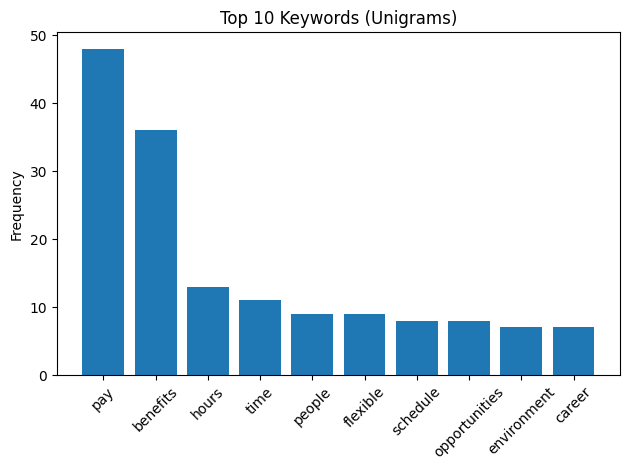

In [ ]:
most_common = filtered_counts.most_common(10)
words, counts = zip(*most_common)

plt.bar(words, counts)
plt.title("Top 10 Keywords (Unigrams)")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
from nltk.util import ngrams

bigrams = list(ngrams(all_words, 2))
trigrams = list(ngrams(all_words, 3))

bigrams_count = Counter(bigrams)
trigrams_count = Counter(trigrams)

In [ ]:
print(bigrams_count.most_common(5))

[(('good', 'pay'), 20), (('pay', 'benefits'), 8), (('good', 'benefits'), 8), (('pay', 'good'), 6), (('great', 'benefits'), 5)]


In [ ]:
print(trigrams_count.most_common(5))

[(('hours', 'good', 'pay'), 3), (('competitive', 'pay', 'benefits'), 3), (('good', 'pay', 'good'), 3), (('work', 'lot', 'learn'), 2), (('good', 'pay', 'benefits'), 2)]


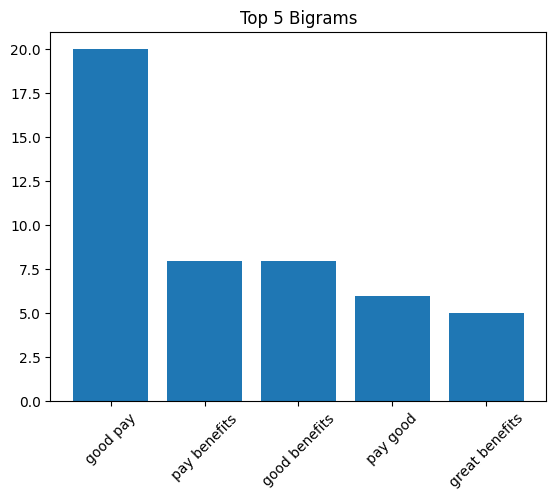

In [ ]:
common_bigrams = bigrams_count.most_common(5)
bg_labels = [' '.join(bg) for bg, count in common_bigrams]
bg_counts = [count for bg, count in common_bigrams]

plt.bar(bg_labels, bg_counts)
plt.title('Top 5 Bigrams')
plt.xticks(rotation=45)
plt.show()

In [ ]:
filtered_bigrams = list(ngrams(filtered_words, 2))
filtered_bigrams_count = Counter(filtered_bigrams)

print(filtered_bigrams_count.most_common(10))

[(('pay', 'benefits'), 10), (('decent', 'pay'), 4), (('flexible', 'schedule'), 3), (('hours', 'pay'), 3), (('pay', 'flexible'), 3), (('competitive', 'pay'), 3), (('leave', 'whenever'), 2), (('people', 'pay'), 2), (('schedule', 'flexibility'), 2), (('4', 'day'), 2)]


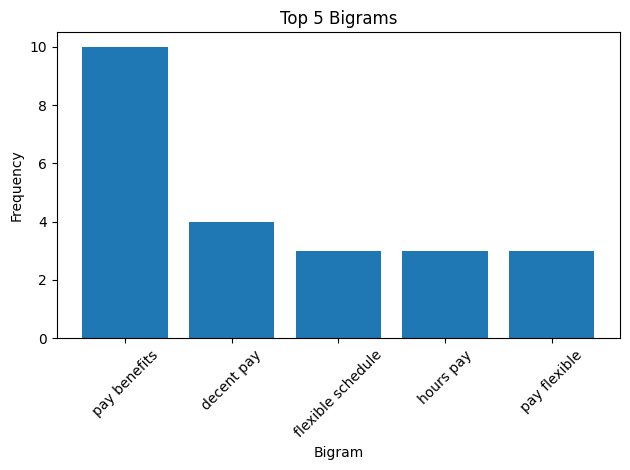

In [ ]:
common_bigrams = filtered_bigrams_count.most_common(5)
bg_labels = [' '.join(bg) for bg, count in common_bigrams]
bg_counts = [count for bg, count in common_bigrams]

plt.bar(bg_labels, bg_counts)
plt.title('Top 5 Bigrams')
plt.xlabel('Bigram')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

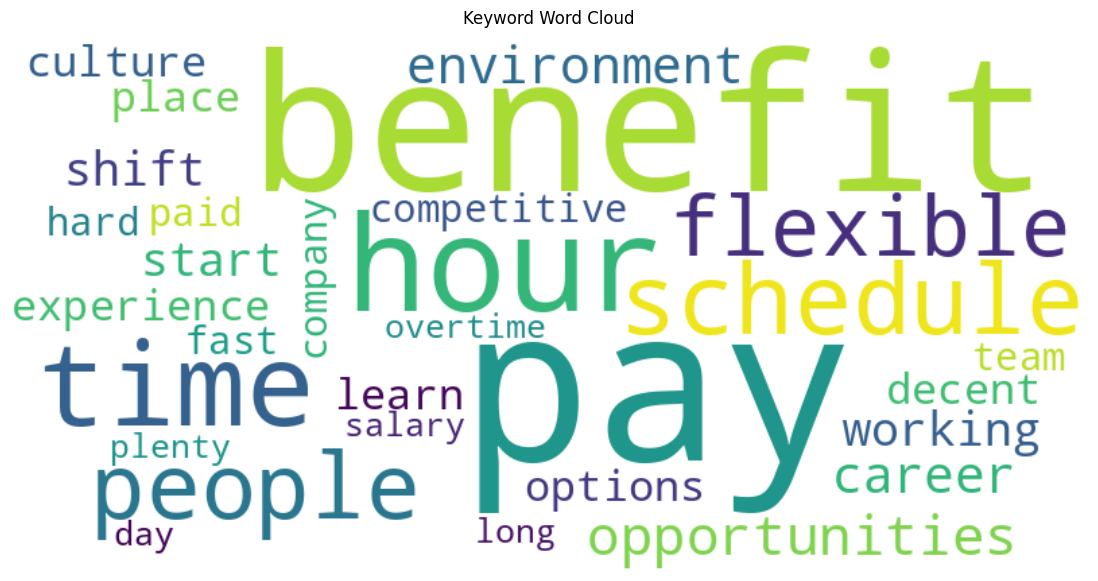

In [ ]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=30).generate(' '.join(filtered_words))

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Keyword Word Cloud")
colormap = 'set4'
plt.show()